# Grids of SNEC models
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [122]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import (SNEC_output_parser, plot_vel_radius_at_time_t,
                      plot_mass_radius, plot_v_radius_time, get_times, sci_to_latex,
                      plot_LC, plot_rho_pfile, get_innerBC_t)
import astropy.units as u
import glob
from itertools import cycle
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
tmax = (24)*u.h

# define colormap -- to use time in hours as color value
Ncolors = 100
colors = plt.get_cmap('viridis', Ncolors)
norm = mpl.colors.Normalize(vmin=0,vmax=tmax.to(u.h).value)

sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])


In [124]:
def get_energy_from_folder(folder):
    return float(folder.split("_e_")[-1].rstrip("/").replace("d", "e"))

In [127]:
root = "/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/" # 15Msun_progenitor/ # s30VdJNL_0.33/"
models = sorted(glob.glob(root+"*.*/"), key=get_energy_from_folder)
print(models)
print(len(models))
BE = 0.64589366106874414e51 *u.erg # see Table 2 in Morozova et al. 2015

['/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/']
2


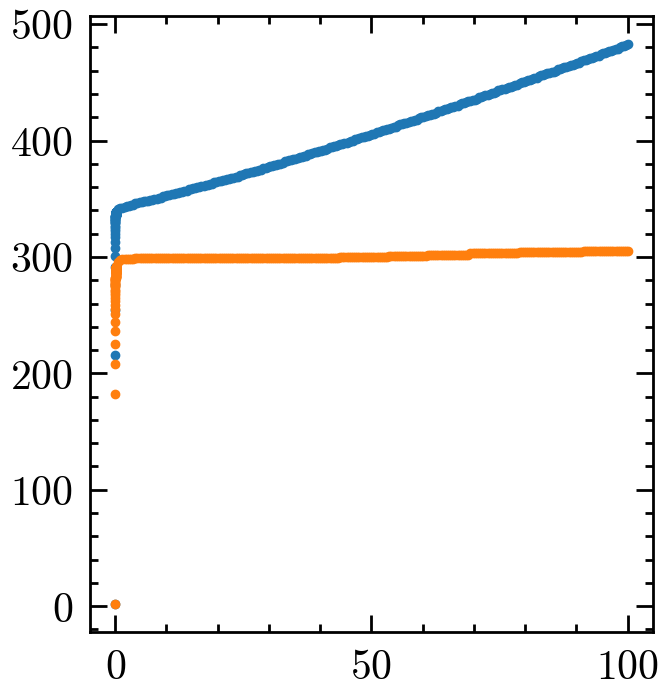

In [133]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])

for m in models:
    t, iBC = get_innerBC_t(m+'Data/inner_boundary.dat')
    ax.scatter(t.to(u.d), iBC)


/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0/


IsADirectoryError: [Errno 21] Is a directory: '/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0//Data'

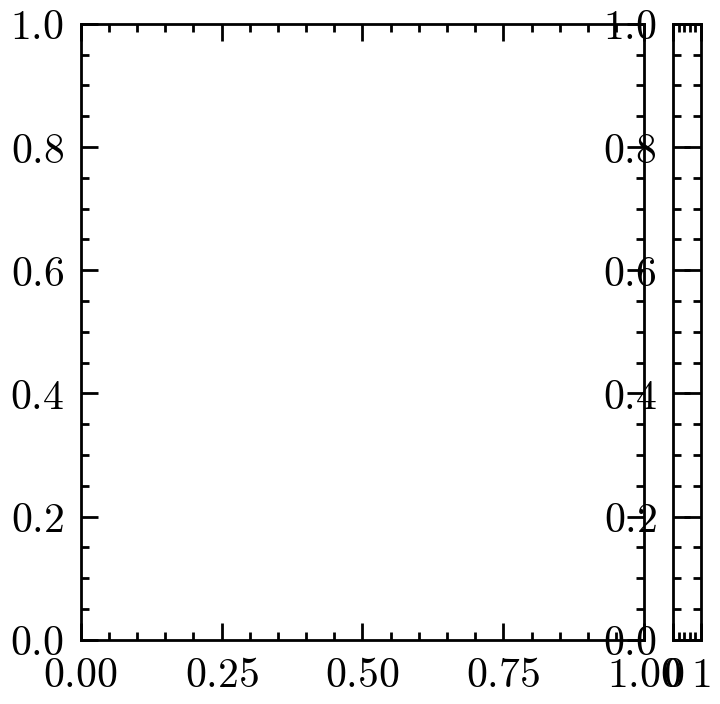

IsADirectoryError: [Errno 21] Is a directory: '/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0//Data'

In [137]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
linestyles = ["-", ":"]
minr=1e99*u.cm

for j, m in enumerate(models):
    print(m)
    if True: #try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        tiBC, iBC = get_innerBC_t(m+'/Data')
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):
            m, r, p = plot_mass_radius(t, outfile, ax=ax, scatter=True, i_min=iBC[i],
                                       alpha=0.5, # s=10*(1+i),
                                       # color=colors[j],
                                       ls = linestyles[j],
                                       # label = f"{t.to(u.h).value:.1f}",
                                       lw=3+j,
                                       vmin = 0,
                                       vmax = tmax.to(u.h).value
                                       )
            # print(linestyles[j])
            if t >= tmax: break
            if min(r)<minr: minr = min(r)
    # except:
    #     print("FAILED")
    #     pass
plt.colorbar(p, cax=cax, norm=norm)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=0, xmax=(1.4*u.Msun+bomb_spread.to(u.Msun)).value, alpha=0.5, color="#808080")
# ax.set_xlim(0, 7.0)
# ax.set_yscale('log')
# ax.set_yscale('symlog',linthresh=1.5e11, linscale=0.66)
# ax.set_ylim(1e8, 1e13)
ax.set_ylim(minr.to(u.cm).value, 1.0e14)
cax.set_ylabel(r"time [h]")
ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")
ax.plot(np.nan, np.nan, c='k', ls='-', label=f"{sci_to_latex(get_energy_from_folder(models[0]))}")
ax.plot(np.nan, np.nan, c='k', ls=':', label=f"{sci_to_latex(get_energy_from_folder(models[-1]))}")
ax.legend(title=r"$E_{\rm expl} \ [\mathrm{erg}]$", frameon=True)

/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0/


(1000,) [1.42216453 3.75533788 4.16963969 4.40949864 4.57303882 4.68206562
 4.75838437 4.81289777 4.85650848 4.88921652 4.91102188 4.93282724
 4.9546326  4.96553528 4.98734063 4.98734063 4.99824331 5.00914599
 5.02004867 5.02004867 5.03095135 5.03095135 5.04185403 5.04185403
 5.04185403 5.05275671 5.05275671 5.05275671 5.06365939 5.06365939
 5.06365939 5.06365939 5.06365939 5.06365939 5.07456207 5.07456207
 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207
 5.07456207 5.07456207 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.11817279 5.12907546 5.12907546
 5.13997814 5.15088082 5.15088082 5.1617835  5.1617835

(1000,) [1.42216453 3.75533788 4.16963969 4.40949864 4.57303882 4.68206562
 4.75838437 4.81289777 4.85650848 4.88921652 4.91102188 4.93282724
 4.9546326  4.96553528 4.98734063 4.98734063 4.99824331 5.00914599
 5.02004867 5.02004867 5.03095135 5.03095135 5.04185403 5.04185403
 5.04185403 5.05275671 5.05275671 5.05275671 5.06365939 5.06365939
 5.06365939 5.06365939 5.06365939 5.06365939 5.07456207 5.07456207
 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207
 5.07456207 5.07456207 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.11817279 5.12907546 5.12907546
 5.13997814 5.15088082 5.15088082 5.1617835  5.1617835

(1000,) [1.42216453 3.75533788 4.16963969 4.40949864 4.57303882 4.68206562
 4.75838437 4.81289777 4.85650848 4.88921652 4.91102188 4.93282724
 4.9546326  4.96553528 4.98734063 4.98734063 4.99824331 5.00914599
 5.02004867 5.02004867 5.03095135 5.03095135 5.04185403 5.04185403
 5.04185403 5.05275671 5.05275671 5.05275671 5.06365939 5.06365939
 5.06365939 5.06365939 5.06365939 5.06365939 5.07456207 5.07456207
 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207
 5.07456207 5.07456207 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.11817279 5.12907546 5.12907546
 5.13997814 5.15088082 5.15088082 5.1617835  5.1617835

(1000,) [1.42216453 3.75533788 4.16963969 4.40949864 4.57303882 4.68206562
 4.75838437 4.81289777 4.85650848 4.88921652 4.91102188 4.93282724
 4.9546326  4.96553528 4.98734063 4.98734063 4.99824331 5.00914599
 5.02004867 5.02004867 5.03095135 5.03095135 5.04185403 5.04185403
 5.04185403 5.05275671 5.05275671 5.05275671 5.06365939 5.06365939
 5.06365939 5.06365939 5.06365939 5.06365939 5.07456207 5.07456207
 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207 5.07456207
 5.07456207 5.07456207 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475 5.08546475
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743 5.09636743
 5.09636743 5.09636743 5.09636743 5.11817279 5.12907546 5.12907546
 5.13997814 5.15088082 5.15088082 5.1617835  5.1617835

...

(1000,) [1.42216453 3.38464679 3.66811645 3.853462   3.97339147 4.0606129
 4.13693166 4.18054237 4.22415309 4.25686113 4.28956916 4.31137452
 4.33317988 4.35498524 4.36588792 4.38769328 4.39859596 4.40949864
 4.42040132 4.43130399 4.43130399 4.44220667 4.45310935 4.45310935
 4.46401203 4.47491471 4.47491471 4.47491471 4.48581739 4.48581739
 4.49672007 4.49672007 4.49672007 4.50762275 4.50762275 4.50762275
 4.51852543 4.51852543 4.51852543 4.51852543 4.52942811 4.52942811
 4.52942811 4.52942811 4.52942811 4.54033079 4.54033079 4.54033079
 4.54033079 4.54033079 4.54033079 4.55123347 4.55123347 4.55123347
 4.55123347 4.55123347 4.55123347 4.55123347 4.55123347 4.56213615
 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615
 4.56213615 4.56213615 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.62755222 4.6384549  4.64935758
 4.64935758 4.64935758 4.64935758 4.64935758 4.64935758

(1000,) [1.42216453 3.38464679 3.66811645 3.853462   3.97339147 4.0606129
 4.13693166 4.18054237 4.22415309 4.25686113 4.28956916 4.31137452
 4.33317988 4.35498524 4.36588792 4.38769328 4.39859596 4.40949864
 4.42040132 4.43130399 4.43130399 4.44220667 4.45310935 4.45310935
 4.46401203 4.47491471 4.47491471 4.47491471 4.48581739 4.48581739
 4.49672007 4.49672007 4.49672007 4.50762275 4.50762275 4.50762275
 4.51852543 4.51852543 4.51852543 4.51852543 4.52942811 4.52942811
 4.52942811 4.52942811 4.52942811 4.54033079 4.54033079 4.54033079
 4.54033079 4.54033079 4.54033079 4.55123347 4.55123347 4.55123347
 4.55123347 4.55123347 4.55123347 4.55123347 4.55123347 4.56213615
 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615
 4.56213615 4.56213615 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.62755222 4.6384549  4.64935758
 4.64935758 4.64935758 4.64935758 4.64935758 4.64935758

(1000,) [1.42216453 3.38464679 3.66811645 3.853462   3.97339147 4.0606129
 4.13693166 4.18054237 4.22415309 4.25686113 4.28956916 4.31137452
 4.33317988 4.35498524 4.36588792 4.38769328 4.39859596 4.40949864
 4.42040132 4.43130399 4.43130399 4.44220667 4.45310935 4.45310935
 4.46401203 4.47491471 4.47491471 4.47491471 4.48581739 4.48581739
 4.49672007 4.49672007 4.49672007 4.50762275 4.50762275 4.50762275
 4.51852543 4.51852543 4.51852543 4.51852543 4.52942811 4.52942811
 4.52942811 4.52942811 4.52942811 4.54033079 4.54033079 4.54033079
 4.54033079 4.54033079 4.54033079 4.55123347 4.55123347 4.55123347
 4.55123347 4.55123347 4.55123347 4.55123347 4.55123347 4.56213615
 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615
 4.56213615 4.56213615 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.62755222 4.6384549  4.64935758
 4.64935758 4.64935758 4.64935758 4.64935758 4.64935758

(1000,) [1.42216453 3.38464679 3.66811645 3.853462   3.97339147 4.0606129
 4.13693166 4.18054237 4.22415309 4.25686113 4.28956916 4.31137452
 4.33317988 4.35498524 4.36588792 4.38769328 4.39859596 4.40949864
 4.42040132 4.43130399 4.43130399 4.44220667 4.45310935 4.45310935
 4.46401203 4.47491471 4.47491471 4.47491471 4.48581739 4.48581739
 4.49672007 4.49672007 4.49672007 4.50762275 4.50762275 4.50762275
 4.51852543 4.51852543 4.51852543 4.51852543 4.52942811 4.52942811
 4.52942811 4.52942811 4.52942811 4.54033079 4.54033079 4.54033079
 4.54033079 4.54033079 4.54033079 4.55123347 4.55123347 4.55123347
 4.55123347 4.55123347 4.55123347 4.55123347 4.55123347 4.56213615
 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615 4.56213615
 4.56213615 4.56213615 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882 4.57303882
 4.57303882 4.57303882 4.57303882 4.62755222 4.6384549  4.64935758
 4.64935758 4.64935758 4.64935758 4.64935758 4.64935758

Text(0.5, 0, 'Mass coordinate [$M_{\\odot}$]')

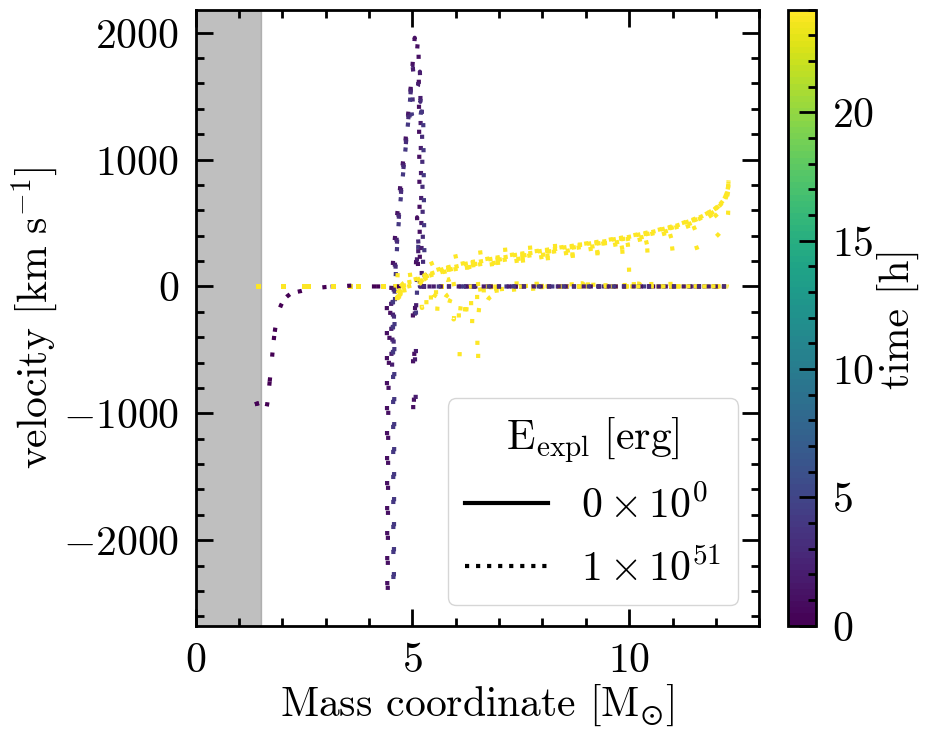

In [121]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

ls = linestyles = [
    (0, (1, 10)),
    (0, (1, 5)),
    (0, (1, 1)),
    
    (5, (10, 3)),
    (0, (5, 10)),] # to distinguish models

plt.colorbar(sm, cax=cax, # ticks=np.linspace(0,2,N), 
             # boundaries=np.arange(-0.05,2.1,.1)
             )
cax.set_ylabel(r"time [h]")

skip=20
for j, m in enumerate(models): # [models[0], models[-1]]):
    print(m)
    times = get_times(m+'Data/mass.xg')
    tiBC, iBC = get_innerBC_t(m)
    for i, t in enumerate(times[::skip]):
        k = np.argmin(np.absolute(times[::skip]-t))
        mm, v, p = plot_vel_radius_at_time_t(t, m+'/Data/vel.xg', ax=ax,
                                             # vmin = min(times[:10].to(u.h).value),
                                             # vmax = max(times[:10].to(u.h).value),
                                             c=colors(norm(t.to(u.h).value)),
                                             ls=linestyles[j],
                                             scatter=False
                                             )
        print(np.shape(mm))
        # ax.axvline(mm[j, iBC].to(u.Msun).value, 0,1,c=colors(norm(t.to(u.h).value)))

        
ax.plot(np.nan, np.nan, c='k', ls='-', label=f"{sci_to_latex(get_energy_from_folder(models[0]))}")
ax.plot(np.nan, np.nan, c='k', ls=':', label=f"{sci_to_latex(get_energy_from_folder(models[-1]))}")

cax.set_ylabel(r"time [h]")
ax.set_xlim(0,13)
ax.axvspan(xmin=0, xmax=1.4+bomb_spread.to(u.Msun).value, alpha=0.5, color="#808080")
ax.legend(title=r"$E_{\rm expl} \ [\mathrm{erg}]$", frameon=True)
# ax.set_ylim(-1000, 1000)
ax.set_ylabel(r"velocity [$\mathrm{km\ s^{-1}}$]")
ax.set_xlabel(r"Mass coordinate [$M_{\odot}$]")

AttributeError: 'str' object has no attribute 'to'

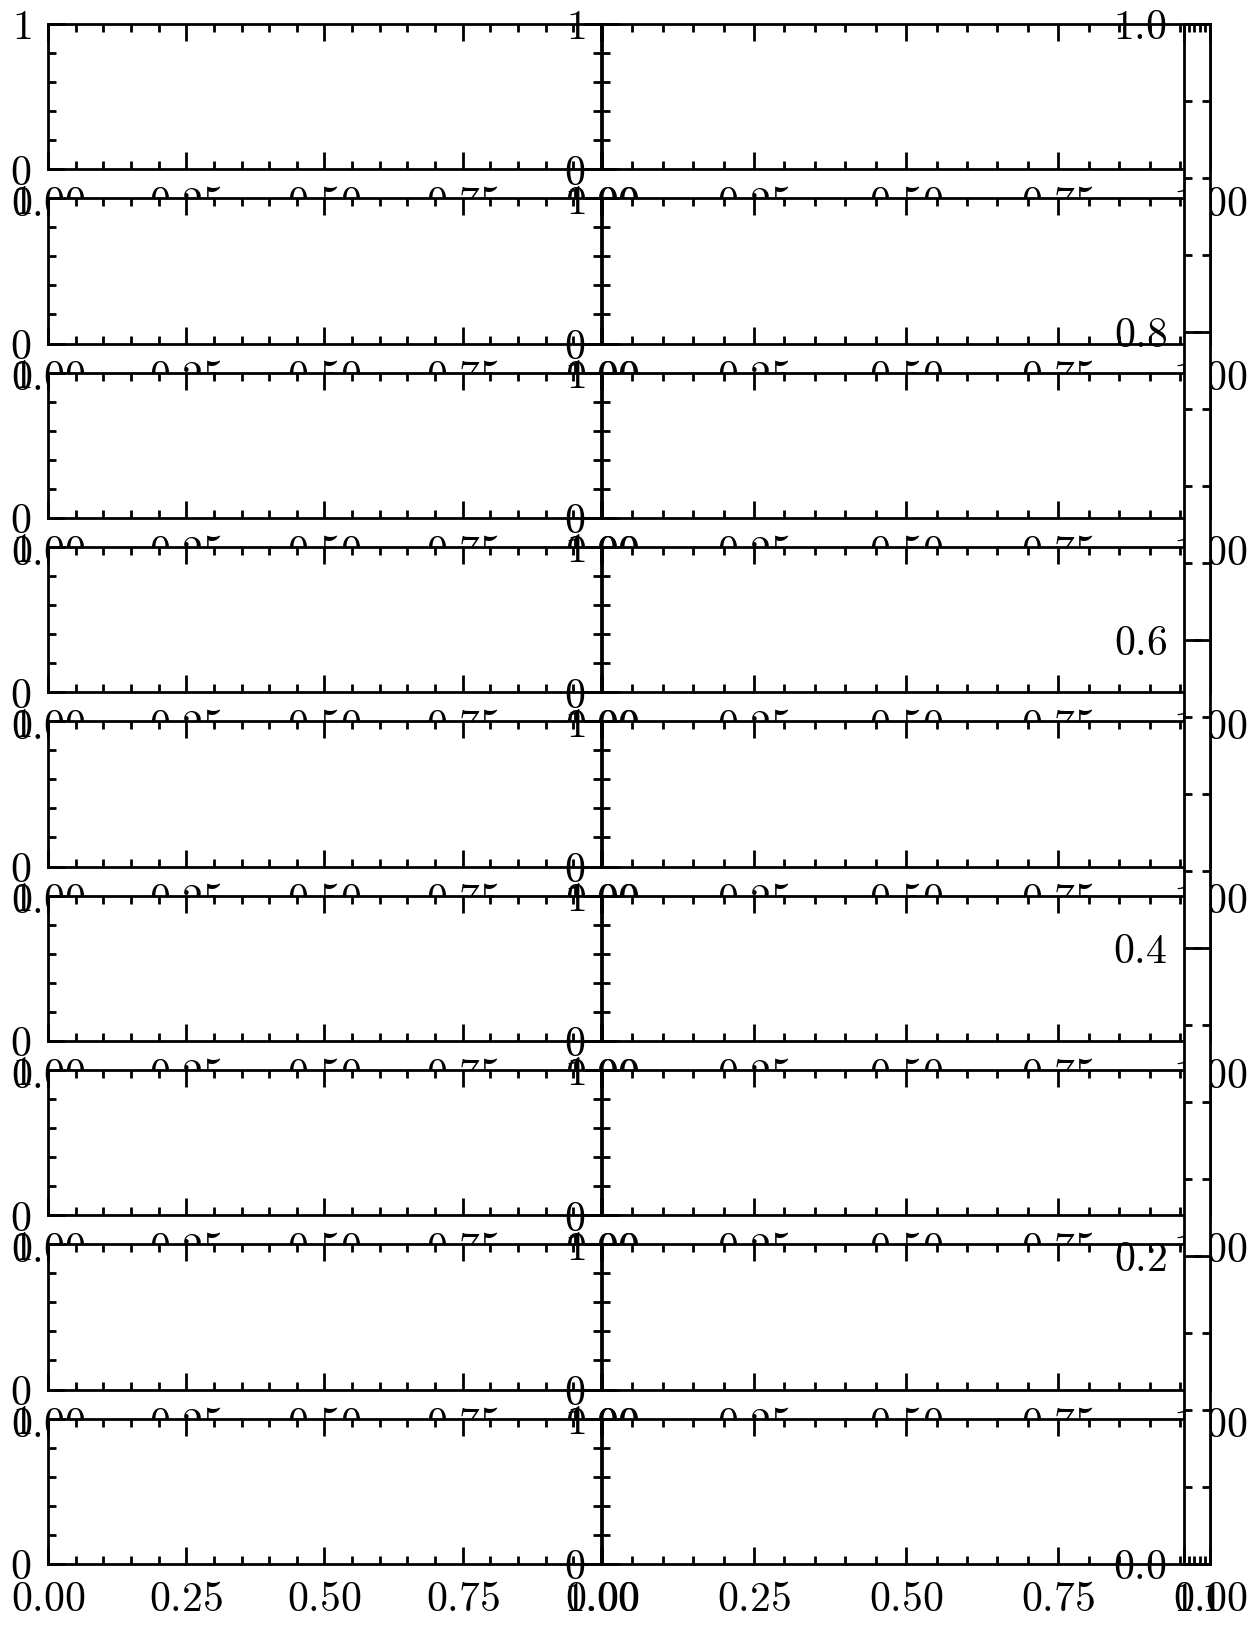

AttributeError: 'str' object has no attribute 'to'

In [35]:
fig = plt.figure(figsize=(15,20))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*.*/"), key=get_energy_from_folder)
# print(len(models15), models15)
for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times):
            # print(t.to(u.h))
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            xmin = min(m.to(u.Msun))               
    except:
        print("FAILED")
        pass

s30 = "/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/"
models30 = sorted(glob.glob(s30+"*.*/"), key=get_energy_from_folder)
# print(len(models30), models30)
for j, m in enumerate(models30):
    ax = axes[2*j+1]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        for i, t in enumerate(times):
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            
    except:
        print("FAILED")
        pass
xmin = min(m.to(u.Msun))
plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")

for i, ax in enumerate(axes):
    # ax.set_xlim(0, 5.0)
    ax.set_yscale('log')
    if (i%2 !=0): ax.set_yticklabels([])
    if (i != 16) and (i !=17): ax.set_xticklabels([])
    
axes[0].set_title(r"$15M_{\odot}$ RSG", size=30)
axes[1].set_title(r"$30M_{\odot}$ WR", size=30)
axes[16].set_xlabel(r"mass coordinate [$M_{\odot}$]")
axes[17].set_xlabel(r"mass coordinate [$M_{\odot}$]")
cax.set_ylabel(r"time [h]")
# ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
# ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$") 

In [ ]:
fig = plt.figure(figsize=(20,30))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*/*.*/"), key=get_energy_from_folder)

for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        vel_file = m+'Data/vel.xg'
        mass_file = m+'Data/mass.xg'
        times = get_times(vel_file)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):           
            m, r, p = plot_v_radius_time(t, vel_file, mass_file,
                                         ax=ax, alpha=0.5, # s=10*(1+i),
                                         # c=colors[j],
                                         # ls = linestyles[j],
                                         label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=240)
            xmin = min(m.to(u.Msun))
    except:
        print("FAILED")
        pass


0.0 erg / s 9.3532836059e+41 erg / s
0.0 erg / s 9.3532836059e+41 erg / s
0.0 erg / s 9.3532836059e+41 erg / s


/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:440: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

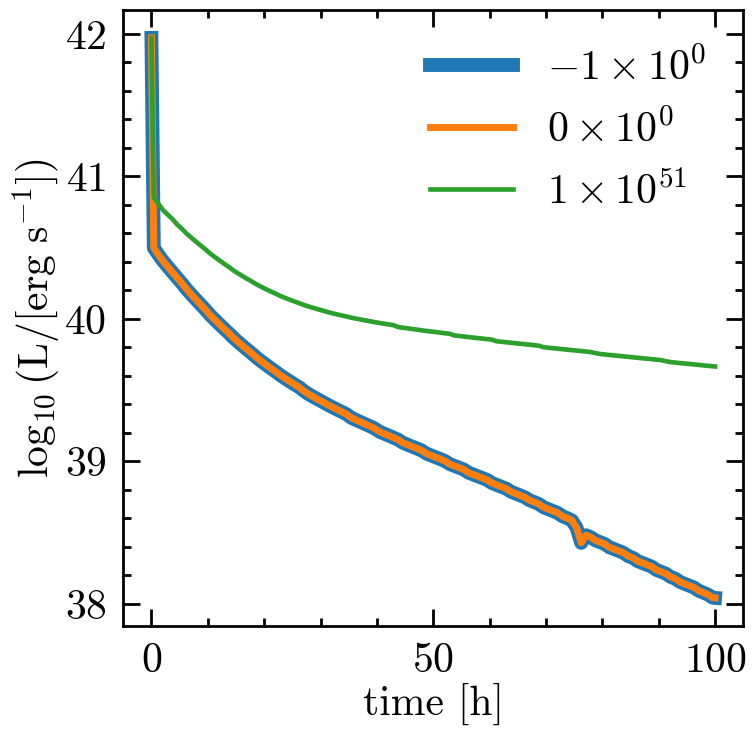

In [11]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, m in enumerate(models):
    # try:
    fname = m+'/Data/lum_observed.dat'
    L, t = plot_LC(fname, ax=ax, label=sci_to_latex(get_energy_from_folder(m)), lw=10/(i+1))
    print(min(L), max(L))
    # except: # IndexError:
    #     pass
    #    print(m, "failed")
    
ax.legend()
ax.set_xlabel(r"time [h]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")

0.0 s 8640000.0 s


0.0 s 8640000.0 s


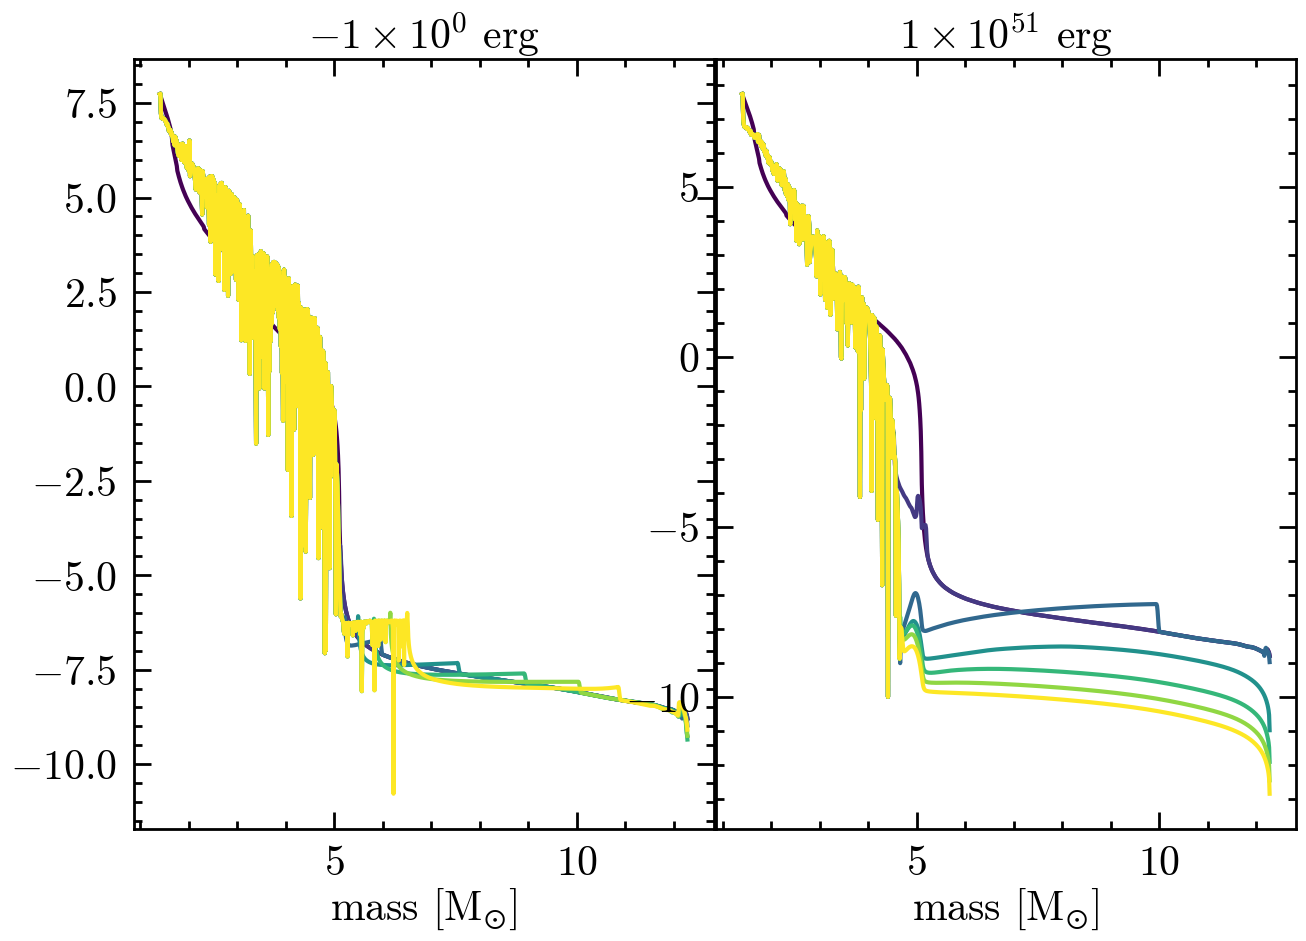

In [20]:
# density profiles
fig = plt.figure(figsize=(15,10))
gs = gridspec.GridSpec(100, 100)
ax1 = fig.add_subplot(gs[:, :50])
ax2 = fig.add_subplot(gs[:, 50:])
axes = [ax1, ax2]
skip = 50

for j, m in enumerate([models[0], models[-1]]):
    ax = axes[j]
    ax.set_title(f"{sci_to_latex(get_energy_from_folder(m))} erg", size=30)
    ax.set_xlabel(r"mass [$M_{\odot}$]")
    try:
        outfile = m+'Data/rho.xg'
        times = get_times(outfile)
        colors = plt.cm.viridis(np.linspace(0,1, len(times[::skip])))
        for i, t in enumerate(times[::skip]):
            plot_rho_pfile(t, outfile, ax=ax, color=colors[i])
    except:
        print(m)
        